# ALgorithme génétique

Réduisez `GENERATIONS` et `POPULATION_SIZE` si vous voulez des runs plus rapides dans le notebook.

In [1]:
import random
import heapq
from functools import lru_cache
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    HAS_MATPLOTLIB = False

In [ ]:
import random
import pandas as pd

# =========================
# 0) Données (depuis ton message)
# =========================
SKILLS = ["C1","C2","C3","C4","C5","C6"]

PATTERNS = {
    1: [[("C1", 2)], [("C1", 1), ("C2", 1)], [], [], [("C4", 1), ("C5", 2), ("C6", 1)]],
    2: [[("C2", 1), ("C3", 1)], [("C3", 1)], [], [], []],
    3: [[("C3", 2)], [("C5", 1)], [], [], []],
    4: [[("C4", 2)], [("C3", 1)], [], [("C1", 1), ("C2", 1)], []],
    5: [[("C2", 1)], [("C4", 1), ("C5", 1)], [], [], []],
    6: [[("C1", 1)], [], [("C3", 1)], [], []],
    7: [[("C6", 2)], [("C1", 1)], [], [], []],
    8: [[("C3", 1), ("C5", 1)], [("C1", 1)], [], [], []],
    9: [[("C5", 1)], [], [], [], []],
    10:[[("C4", 1)], [("C4", 1), ("C5", 1)], [("C1", 1), ("C2", 1)], [], []],
}

SCENARIOS = [("J1",10),("J2",15),("J3",19),("J4",34),("J5",43),("J6",50)]
GLOBAL_SEED = 2025

# Capacités (1 par compétence comme dans Tabou permutation) [file:4]
taskcapacity = {s: 1 for s in SKILLS}

# =========================
# 1) Génération patients 1..N
# =========================
def build_patients_operations(N, seed=GLOBAL_SEED):
    """
    Retourne une liste 'patientsoperations' (taille N)
    où chaque patient est une liste de 5 stages,
    et chaque stage est une liste de tokens 'Ck' répétés selon durée.
    Format compatible avec preprocesspatientsops de Recherche-Tabou.ipynb. [file:4]
    """
    rng = random.Random(seed)

    # helper: ("C1",2) -> ["C1","C1"]
    def op_to_tokens(op_list):
        tokens = []
        for skill, dur in op_list:
            tokens += [skill] * int(dur)
        return tokens

    patientsops = []
    for pid in range(1, N+1):
        if pid <= 10:
            pattern = PATTERNS[pid]
        else:
            pattern = PATTERNS[rng.randint(1, 10)]

        # 5 stages
        stages = []
        for stage in pattern:
            stages.append(op_to_tokens(stage))
        patientsops.append(stages)

    return patientsops

# =========================
# 2) Hooks à remplir (AG / RS)
# =========================


def run_AG(patientsops, seed):
    """
    Retourne un scalaire: meilleur coût (Cmax) trouvé par le GA.
    Appel EXACT au GA de Algorithme-genetique-2.ipynb via buildtasksandpredecessors + runga + fitnessvalue. [file:3]
    """

    # --- Vérifs: ces symboles doivent venir de Algorithme-genetique-2.ipynb [file:3]
    required = ["buildtasksandpredecessors", "runga", "fitnessvalue"]
    missing = [k for k in required if k not in globals()]
    if missing:
        raise RuntimeError(
            "Charge d'abord Algorithme-genetique-2.ipynb (cells buildtasksandpredecessors / fitnessvalue / runga). "
            f"Manquants: {missing}"
        )

    # --- Convertit une liste de tokens (ex: ["C1","C1","C2"]) -> [("C1",2), ("C2",1)]
    def tokens_to_opdef(tokens):
        out = []
        if not tokens:
            return out
        cur = tokens[0]
        cnt = 1
        for t in tokens[1:]:
            if t == cur:
                cnt += 1
            else:
                out.append((cur, cnt))
                cur = t
                cnt = 1
        out.append((cur, cnt))
        return out

    # --- Construire P au format du notebook GA [file:3]
    # P: dict patient -> liste de 5 opérations; une opération = liste (skill, multiplicity)
    P = {}
    for pid, stages in enumerate(patientsops, start=1):
        P[pid] = [tokens_to_opdef(stage) for stage in stages]

    # --- Important: le notebook GA utilise des globals tasks/predecessors/NTASKS/SKILLS [file:3]
    tasks, predecessors = buildtasksandpredecessors(P)
    globals()["tasks"] = tasks
    globals()["predecessors"] = predecessors
    globals()["NTASKS"] = len(tasks)
    globals()["SKILLS"] = sorted({t["skill"] for t in tasks})

    # --- Patch: définir mutate(seq) si absent (bug dans le notebook) [file:3]
    # (swap + insert, comme dans les paramètres MUTATESWAPPROB/MUTATEINSERTPROB du notebook) [file:3]
    import random
    random.seed(seed)

    if "mutate" not in globals():
        def mutate(seq):
            n = len(seq)
            # swap
            if random.random() < globals().get("MUTATESWAPPROB", 0.05):
                i, j = random.sample(range(n), 2)
                seq[i], seq[j] = seq[j], seq[i]
            # insert
            if random.random() < globals().get("MUTATEINSERTPROB", 0.05):
                i, j = random.sample(range(n), 2)
                g = seq.pop(i)
                seq.insert(j, g)
        globals()["mutate"] = mutate

    # --- Lancer GA et récupérer le Cmax
    bestseq, _hist = runga()
    best_cmax = fitnessvalue(bestseq)[0]  # fitnessvalue(seq) retourne (Cmax, SumC, start, end) [file:3]
    return best_cmax



def run_RS(patientsops, seed):
    """
    Retourne un scalaire: meilleur coût (Cmax) trouvé par le Recuit Simulé.
    Appel EXACT au RS/SA du notebook Projet_IA_optimisation_RS.ipynb via recuitsimule + cout. [file:5]
    """

    # --- Vérifs: ces symboles doivent venir de Projet_IA_optimisation_RS.ipynb [file:5]
    required = ["recuitsimule", "cout", "solutioninitiale", "voisin", "estvalide"]
    missing = [k for k in required if k not in globals()]
    if missing:
        raise RuntimeError(
            "Charge d'abord Projet_IA_optimisation_RS.ipynb (cells solutioninitiale/estvalide/voisin/cout/recuitsimule). "
            f"Manquants: {missing}"
        )

    import random
    random.seed(seed)

    # --- Construire patientops au format du notebook RS:
    # patientops[p] = liste d'opérations; chaque opération = liste de tokens skills (ex: ["C1","C1","C2"]) [file:5]
    patientops = {}
    for pid, stages in enumerate(patientsops, start=1):
        # stages: liste de 5 listes de tokens
        patientops[pid] = [list(stage) for stage in stages]

    # --- Définir les globals attendus par le notebook RS [file:5]
    globals()["patientops"] = patientops
    globals()["patients"] = list(patientops.keys())
    # skills: union des tokens présents (dans le notebook ils fixent C1..C6, ici on le déduit) [file:5]
    all_skills = sorted({s for ops in patientops.values() for op in ops for s in op})
    globals()["skills"] = all_skills

    # --- Lancer recuit (paramètres par défaut du notebook: t0=1000, alpha=0.95, tmin=0.1, itercycle=100) [file:5]
    assignbest, fbest = recuitsimule()

    # fbest = cout(assignbest) = makespan (max longueur des listes par compétence) [file:5]
    return fbest

# =========================
# 3) TABOU permutation (Recherche-Tabou)
# =========================
def run_TABOU(patientsops, seed, maxiter=800, tabutenure=7, stopnoimprove=30):
    """
    Utilise tabusearch(...) si disponible, sinon TSAgent. [file:4]
    Retourne bestcost (makespan units).
    """
    # Ces symboles doivent être déjà chargés depuis Recherche-Tabou.ipynb [file:4]
    if "preprocesspatientsops" not in globals() or "simulate" not in globals():
        raise RuntimeError("Charge d'abord Recherche-Tabou.ipynb (cellules preprocesspatientsops/simulate).")

    stages = preprocesspatientsops(patientsops)

    if "tabusearch" in globals():
        bestcost, bestorder = tabusearch(
            stages, taskcapacity,
            maxiter=maxiter, tabutenure=tabutenure, stopnoimprove=stopnoimprove,
            seed=seed
        )
        return bestcost

    if "TSAgent" in globals():
        ag = TSAgent(name="TS", maxiter=maxiter, seed=seed)
        ag.step(stages=stages, capacities=taskcapacity, runs=1, verbose=False)
        return ag.bestcost

    raise RuntimeError("Ni tabusearch(...) ni TSAgent trouvés dans le kernel (Recherche-Tabou.ipynb).")

# =========================
# 4) Agents & Agents apprentissage (simple)
# =========================
def agent_wrapper_tabou(patientsops, seed, runs=3):
    """Agent Tabou = plusieurs runs indépendants et on prend le meilleur. [file:4]"""
    best = float("inf")
    for r in range(runs):
        c = run_TABOU(patientsops, seed + 1000*r)
        best = min(best, c)
    return best

def agent_learning_loop(run_fn, patientsops, seed, trials=8):
    """
    Agent + apprentissage (version simple): on teste plusieurs seeds/hyperparams et on garde le meilleur.
    (Tu peux remplacer par ton vrai RL plus tard.)
    """
    best = float("inf")
    for t in range(trials):
        c = run_fn(patientsops, seed + 777*t)
        best = min(best, c)
    return best

# =========================
# 5) Exécution + tableaux séparés
# =========================
def run_all():
    rows_meta = []
    rows_agents = []
    rows_rl = []

    for idx, (jour, N) in enumerate(SCENARIOS):
        seed = GLOBAL_SEED + idx  # seed différent par jour

        patientsops = build_patients_operations(N, seed=seed)

        # --- Metaheuristiques
        ag_cost = run_AG(patientsops, seed)      # à remplir [file:3]
        rs_cost = run_RS(patientsops, seed)      # à remplir [file:5]
        tabu_cost = run_TABOU(patientsops, seed) # ok [file:4]

        rows_meta.append({
            "Jour": jour, "Nombre de patients": N,
            "AG": ag_cost, "Tabou": tabu_cost, "RS": rs_cost
        })

        # --- Agents (exemple: multi-runs)
        agent_ag = ag_cost     # remplace par ton vrai agent_AG si tu en as
        agent_rs = rs_cost     # remplace par ton vrai agent_RS
        agent_tabu = agent_wrapper_tabou(patientsops, seed, runs=3)

        rows_agents.append({
            "Jour": jour, "Nombre de patients": N,
            "Agent_AG": agent_ag, "Agent_Tabou": agent_tabu, "Agent_RS": agent_rs
        })

        # --- Agents + apprentissage (version simple: meilleure config sur plusieurs essais)
        rl_ag = agent_learning_loop(lambda pops, sd: run_AG(pops, sd), patientsops, seed, trials=8)
        rl_rs = agent_learning_loop(lambda pops, sd: run_RS(pops, sd), patientsops, seed, trials=8)
        rl_tabu = agent_learning_loop(lambda pops, sd: run_TABOU(pops, sd), patientsops, seed, trials=8)

        rows_rl.append({
            "Jour": jour, "Nombre de patients": N,
            "Agent_AG": rl_ag, "Agent_Tabou": rl_tabu, "Agent_RS": rl_rs
        })

    df_meta = pd.DataFrame(rows_meta)
    df_agents = pd.DataFrame(rows_agents)
    df_rl = pd.DataFrame(rows_rl)

    display(df_meta)
    display(df_agents)
    display(df_rl)

    df_meta.to_csv("table_metaheuristique.csv", index=False)
    df_agents.to_csv("table_agents.csv", index=False)
    df_rl.to_csv("table_agents_apprentissage.csv", index=False)

    return df_meta, df_agents, df_rl

# Lance tout
df_meta, df_agents, df_rl = run_all()


In [2]:
# ==== PARAMÈTRES GÉNÉTIQUES ====
DURATION_PER_TASK = 1
POPULATION_SIZE = 20  # smaller = faster
CROSSOVER_PROB = 0.075
MUTATE_SWAP_PROB = 0.05
MUTATE_INSERT_PROB = 0.05
GENERATIONS = 200  # reduced for notebook demo

random.seed(1)  # reproductibility

In [3]:
# ==== DÉFINITION DU PROBLÈME ====
P = {
    1: [[("C1", 2)], [("C1", 1), ("C2", 1)], [], [], [("C4", 1), ("C5", 2), ("C6", 1)]],
    2: [[("C2", 1), ("C3", 1)], [("C3", 1)], [], [], []],
    3: [[("C3", 2)], [("C5", 1)], [], [], []],
    4: [[("C4", 2)], [("C3", 1)], [], [("C1", 1), ("C2", 1)], []],
    5: [[("C2", 1)], [("C4", 1), ("C5", 1)], [], [], []],
    6: [[("C1", 1)], [], [("C3", 1)], [], []],
    7: [[("C6", 2)], [("C1", 1)], [], [], []],
    8: [[("C3", 1), ("C5", 1)], [("C1", 1)], [], [], []],
    9: [[("C5", 1)], [], [], [], []],
    10: [[("C4", 1)], [("C4", 1), ("C5", 1)], [("C1", 1), ("C2", 1)], [], []],
}

In [4]:
# ==== CONSTRUCTION DES TÂCHES ET PRÉCÉDENCES ====
def build_tasks_and_predecessors(P):
    tasks, predecessors = [], {}
    tid = 0
    for patient in range(1, 11):
        last_task_of_prev_op = None
        for op_index in range(5):
            op_def = P[patient][op_index]
            previous_task_in_op = None
            op_task_ids = []
            for skill, multiplicity in op_def:
                for _ in range(multiplicity):
                    task = {
                        "tid": tid,
                        "patient": patient,
                        "op": op_index + 1,
                        "skill": skill,
                        "dur": DURATION_PER_TASK,
                    }
                    tasks.append(task)
                    predecessors[tid] = set()
                    if previous_task_in_op is not None:
                        predecessors[tid].add(previous_task_in_op)
                    if last_task_of_prev_op is not None:
                        predecessors[tid].add(last_task_of_prev_op)
                    previous_task_in_op = tid
                    op_task_ids.append(tid)
                    tid += 1
            if op_task_ids:
                last_task_of_prev_op = op_task_ids[-1]
    return tasks, predecessors

tasks, predecessors = build_tasks_and_predecessors(P)
N_TASKS = len(tasks)
SKILLS = sorted({t['skill'] for t in tasks})

In [5]:
# ==== PLANIFICATEUR (SCHEDULER) ====
def schedule_serial(priority_order):
    """Strict serial scheduler — no overlaps, full precedence.
    Returns: Cmax, SumC, start_time, end_time
    """
    priority_rank = {tid: pos for pos, tid in enumerate(priority_order)}
    skill_free = {s: 0 for s in SKILLS}
    ready = [t for t in range(N_TASKS) if len(predecessors[t]) == 0]
    scheduled = set()
    start_time, end_time = {}, {}
    current_time = 0

    while len(scheduled) < N_TASKS:
        available = [t for t in ready if skill_free[tasks[t]['skill']] <= current_time]

        if not available:
            # advance to next future event
            next_events = [v for v in skill_free.values() if v > current_time] + [v for v in end_time.values() if v > current_time]
            if not next_events:
                current_time += 1
            else:
                current_time = min(next_events)
            continue

        # choose by GA priority
        tid = min(available, key=lambda x: priority_rank[x])
        ready.remove(tid)
        scheduled.add(tid)
        task = tasks[tid]

        preds_end = max((end_time[p] for p in predecessors[tid]), default=0)
        st = max(current_time, preds_end, skill_free[task['skill']])
        ft = st + task['dur']
        start_time[tid], end_time[tid] = st, ft
        skill_free[task['skill']] = ft
        current_time = st

        # add successors
        for v in range(N_TASKS):
            if v in scheduled or v in ready:
                continue
            if all(pr in end_time for pr in predecessors[v]):
                ready.append(v)

    Cmax = max(end_time.values())
    SumC = sum(end_time.values())
    return Cmax, SumC, start_time, end_time

In [6]:
# ==== FONCTIONS GA ====
@lru_cache(maxsize=None)
def cached_fitness(seq_tuple):
    return schedule_serial(list(seq_tuple))[:2]

def fitness_value(seq):
    return cached_fitness(tuple(seq))

def roulette_select(pop):
    ranked = sorted(pop, key=fitness_value)
    score = {id(indiv): 1.0 / (i + 1) for i, indiv in enumerate(ranked)}
    total = sum(score[id(indiv)] for indiv in pop)
    r, acc = random.random(), 0.0
    for indiv in pop:
        acc += score[id(indiv)] / total
        if acc >= r:
            return indiv[:]
    return pop[-1][:]

def ox_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a : b + 1] = p1[a : b + 1]
    k = 0
    for g in p2:
        if g not in child:
            while child[k] is not None:
                k += 1
            child[k] = g
    return child

def mutate(seq):
    n = len(seq)
    if random.random() < MUTATE_SWAP_PROB:
        i, j = random.sample(range(n), 2)
        seq[i], seq[j] = seq[j], seq[i]
    if random.random() < MUTATE_INSERT_PROB:
        i, j = random.sample(range(n), 2)
        seq.insert(j, seq.pop(i))

def run_ga():
    base = list(range(N_TASKS))
    pop = [random.sample(base, len(base)) for _ in range(POPULATION_SIZE)]
    best_hist, last_best, stable = [], None, 0

    for gen in range(1, GENERATIONS + 1):
        pop.sort(key=fitness_value)
        best_seq = pop[0]
        best_Cmax = fitness_value(best_seq)[0]
        best_hist.append(best_Cmax)
        if gen % 50 == 0:
            print(f"Génération {gen:4d}: meilleur Cmax={best_Cmax}")

        if last_best == best_Cmax:
            stable += 1
            if stable >= 50:
                print(f"Convergence à la génération {gen}")
                break
        else:
            last_best, stable = best_Cmax, 0

        new_pop = []
        while len(new_pop) < POPULATION_SIZE:
            p1, p2 = roulette_select(pop), roulette_select(pop)
            child = ox_crossover(p1, p2) if random.random() < CROSSOVER_PROB else p1[:]
            mutate(child)
            new_pop.append(child)
        pop = new_pop

    pop.sort(key=fitness_value)
    return pop[0][:], best_hist

In [7]:
# ==== VISUALISATION (fallback si pas de matplotlib) ====
def plot_gantt(start, end, title, Cmax):
    if not HAS_MATPLOTLIB:
        print("\n--- GANTT (texte) :", title)
        for tid in sorted(start, key=lambda t: start[t]):
            s = start[tid] * DURATION_PER_TASK
            e = end[tid] * DURATION_PER_TASK
            t = tasks[tid]
            print(f"Task {tid}: Patient {t['patient']} Op{t['op']} | skill={t['skill']} | [{s}, {e})")
        print("--- fin GANTT\n")
        return

    plt.figure(figsize=(10, 5))
    colors = plt.cm.get_cmap("tab20", 10)
    for tid, st in start.items():
        ft = end[tid]
        skill = tasks[tid]["skill"]
        patient = tasks[tid]["patient"]
        y = SKILLS.index(skill)
        plt.barh(y, ft - st, left=st, color=colors(patient - 1), edgecolor="black")
        plt.text(st + 0.1, y, f"P{patient}", va="center", ha="left", fontsize=7)
    plt.axvline(x=Cmax, color="red", linestyle="--", label=f"Cmax={Cmax}")
    plt.yticks(range(len(SKILLS)), SKILLS)
    plt.xlabel("Temps")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# ==== VÉRIFICATION D'OPTIMALITÉ ====
from functools import lru_cache

def critical_path_length():
    # longest path length in precedence graph (sum of durations)
    @lru_cache(maxsize=None)
    def longest_to(tid):
        preds = predecessors.get(tid, set())
        if not preds:
            return tasks[tid]['dur']
        return tasks[tid]['dur'] + max(longest_to(p) for p in preds)

    return max(longest_to(t) for t in range(N_TASKS))

def workload_lower_bound():
    # for each skill, total processing time on that skill (since single machine per skill)
    load = {s: 0 for s in SKILLS}
    for t in tasks:
        load[t['skill']] += t['dur']
    return max(load.values())

def verify_optimality(seq, expected_Cmax=None, do_local_search=True, max_neighbors=1000):
    """Vérifie si `seq` est (provablement) optimale:
    - calcule bornes: longueur de chemin critique et charge max par compétence
    - si Cmax == LB alors solution provablement optimale
    - sinon, optionnellement, teste des voisins (swaps/insert) pour tenter d'améliorer
    Retourne (is_optimal_bool, message, details_dict)
    """
    if expected_Cmax is None:
        Cmax, SumC, start, end = schedule_serial(seq)
    else:
        Cmax, SumC, start, end = schedule_serial(seq)
    cp = critical_path_length()
    wl = workload_lower_bound()
    LB = max(cp, wl)

    details = {
        'Cmax': Cmax,
        'SumC': SumC,
        'critical_path': cp,
        'workload_lb': wl,
        'lower_bound': LB,
    }

    if Cmax == LB:
        return True, f"Provably optimal: Cmax equals lower bound {LB}", details

    if not do_local_search:
        return False, f"Not provably optimal (Cmax={Cmax} > LB={LB}). Local search skipped.", details

    # recherche locale limitée: tester swaps et insertions aléatoires
    best = Cmax
    base = list(seq)
    tried = 0
    rng = random.Random(2)
    while tried < max_neighbors:
        tried += 1
        # choisir un voisin: swap ou insertion
        if rng.random() < 0.5:
            i, j = rng.sample(range(len(base)), 2)
            nb = base[:]
            nb[i], nb[j] = nb[j], nb[i]
        else:
            i, j = rng.sample(range(len(base)), 2)
            nb = base[:]
            g = nb.pop(i)
            nb.insert(j, g)
        val = schedule_serial(nb)[0]
        if val < best:
            return False, f"Found improving neighbor: Cmax {val} < {Cmax}", { 'improving_seq': nb, 'improving_Cmax': val }
    
    return False, f"Not provably optimal (Cmax={Cmax} > LB={LB}). No improving neighbor found in {max_neighbors} trials.", details

=== BASELINE (ordre initial) ===
Cmax = 15
Somme des dates de fin = 274
(False, 'Found improving neighbor: Cmax 14 < 15', {'improving_seq': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 18, 35], 'improving_Cmax': 14})
Génération   50: meilleur Cmax=11
Convergence à la génération 62

=== MEILLEURE SOLUTION GA ===
Cmax = 11
Somme des dates de fin = 161
Gain relatif = 26.67%
(False, 'Found improving neighbor: Cmax 10 < 11', {'improving_seq': [1, 0, 18, 31, 20, 28, 12, 10, 30, 2, 27, 29, 19, 14, 8, 6, 24, 17, 15, 22, 21, 26, 32, 33, 11, 4, 25, 5, 3, 35, 23, 34, 9, 16, 7, 13], 'improving_Cmax': 10})


C:\Users\HI\AppData\Local\Temp\ipykernel_19668\411573825.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", 10)


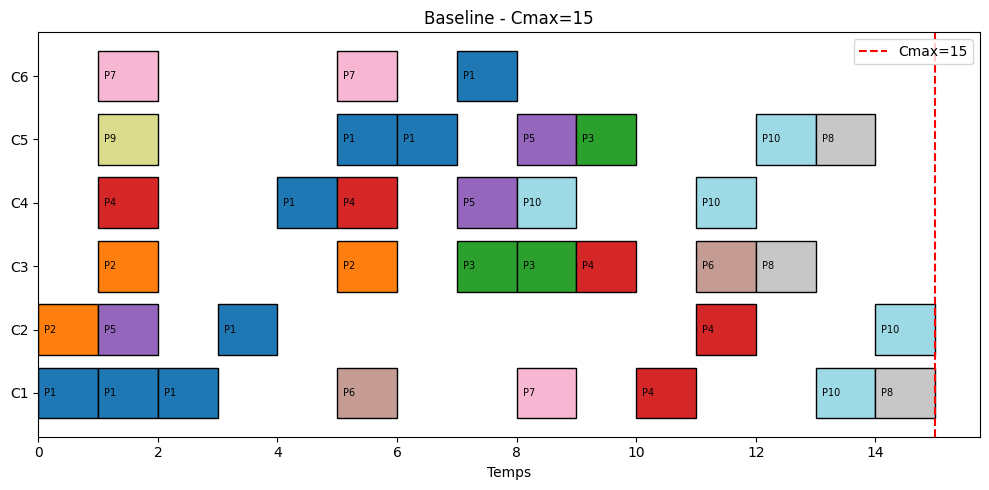

C:\Users\HI\AppData\Local\Temp\ipykernel_19668\411573825.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", 10)


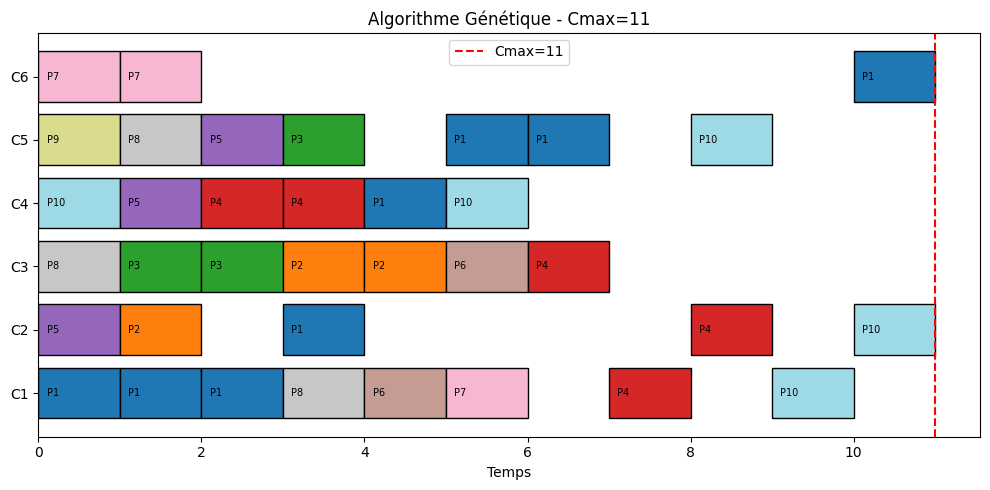

In [ ]:
# ==== RUN DEMO ====
# baseline
baseline = list(range(N_TASKS))
Cmax_b, SumC_b, start_b, end_b = schedule_serial(baseline)
print("=== BASELINE (ordre initial) ===")
print(f"Cmax = {Cmax_b}")
print(f"Somme des dates de fin = {SumC_b}")
ok_b, msg_b, details_b = verify_optimality(baseline)
print(f"Vérification baseline: {ok_b} - {msg_b}")
if not ok_b:
    print("Détails:", details_b)

# run GA (rapide dans notebook)
best_seq, hist = run_ga()
Cmax_g, SumC_g, start_g, end_g = schedule_serial(best_seq)
print("\n=== MEILLEURE SOLUTION GA ===")
print(f"Cmax = {Cmax_g}")
print(f"Somme des dates de fin = {SumC_g}")
print(f"Gain relatif = {(100 * (Cmax_b - Cmax_g) / Cmax_b if Cmax_b > 0 else 0):.2f}%")
ok_g, msg_g, details_g = verify_optimality(best_seq)
print(f"Vérification GA: {ok_g} - {msg_g}")
if not ok_g:
    print("Détails:", details_g)

# afficher GANTT (texte ou graphique)
plot_gantt(start_b, end_b, f"Baseline - Cmax={Cmax_b}", Cmax_b)
plot_gantt(start_g, end_g, f"Algorithme Génétique - Cmax={Cmax_g}", Cmax_g)